# Import Library

In [15]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

PIL → untuk membaca & menyimpan gambar
numpy → untuk manipulasi array pixel
matplotlib → untuk menampilkan gambar

# Utility Function

In [21]:
def int_to_bin(n):
    return format(n, '032b')

def bin_to_int(b):
    return int(b, 2)

Mengubah angka → biner (32 bit)
Mengubah biner → angka

Digunakan untuk:

menyimpan metadata gambar (tinggi, lebar, channel)

# Encode (Embedding)

In [22]:
def encode_image(cover_path, secret_path, output_path):
    cover = Image.open(cover_path).convert("RGB")
    secret = Image.open(secret_path).convert("RGB")

    # Resize secret (aman)
    secret = secret.resize((100, 100))

    cover_arr = np.array(cover)
    secret_arr = np.array(secret)

    flat_secret = secret_arr.flatten()
    binary_secret = ''.join(format(i, '08b') for i in flat_secret)

    h, w, c = secret_arr.shape
    metadata = int_to_bin(h) + int_to_bin(w) + int_to_bin(c)

    data = metadata + binary_secret

    flat_cover = cover_arr.flatten()

    if len(data) > len(flat_cover):
        raise ValueError("Cover tidak cukup besar")

    # FIX overflow → pakai 254
    for i in range(len(data)):
        flat_cover[i] = (flat_cover[i] & 254) | int(data[i])

    stego = flat_cover.reshape(cover_arr.shape)

    Image.fromarray(stego.astype('uint8')).save(output_path)

    print("✔ Embedding berhasil:", output_path)

Encode → menyisipkan gambar ke dalam gambar

# Decode (Extraction)

In [23]:
def decode_image(stego_path, output_path):
    stego = Image.open(stego_path).convert("RGB")
    arr = np.array(stego).flatten()

    binary_data = ''.join(str(pixel & 1) for pixel in arr)

    h = bin_to_int(binary_data[:32])
    w = bin_to_int(binary_data[32:64])
    c = bin_to_int(binary_data[64:96])

    data_start = 96
    total_bits = h * w * c * 8

    image_bits = binary_data[data_start:data_start + total_bits]

    bytes_data = [image_bits[i:i+8] for i in range(0, len(image_bits), 8)]
    pixels = [bin_to_int(b) for b in bytes_data]

    img_arr = np.array(pixels, dtype=np.uint8).reshape((h, w, c))

    Image.fromarray(img_arr).save(output_path)

    print("✔ Extraction berhasil:", output_path)

Decode → mengambil kembali gambar tersebut

# Eksekusi

In [26]:
encode_image("/content/2.png", "/content/secret1.png", "/content/stego.png")
decode_image("/content/stego.png", "/content/extracted.png")

✔ Embedding berhasil: /content/stego.png
✔ Extraction berhasil: /content/extracted.png


proses penyisipan
proses ekstraksi

# Visualisasi

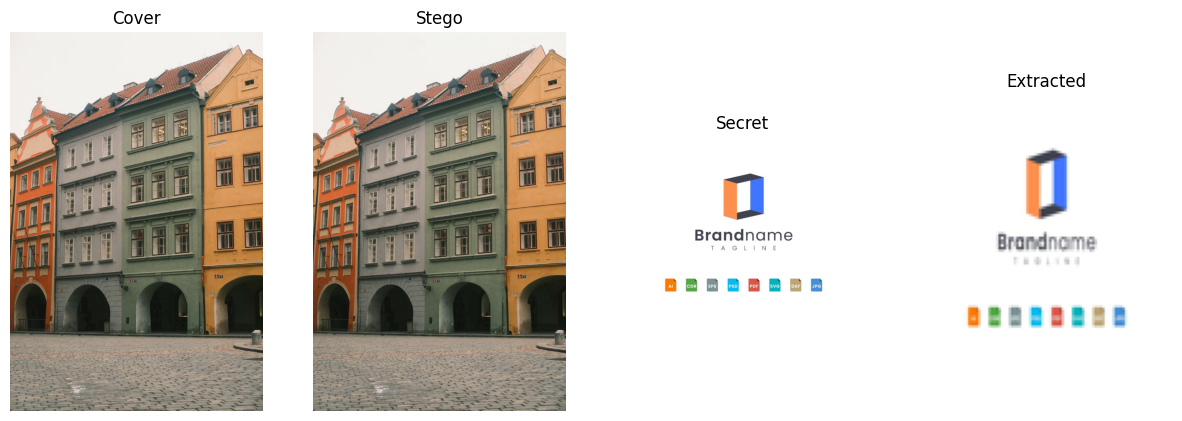

In [27]:
def show_images():
    cover = Image.open("/content/2.png")
    stego = Image.open("/content/stego.png")
    secret = Image.open("/content/secret1.png")
    extracted = Image.open("/content/extracted.png")

    fig, ax = plt.subplots(1,4, figsize=(15,5))

    ax[0].imshow(cover)
    ax[0].set_title("Cover")

    ax[1].imshow(stego)
    ax[1].set_title("Stego")

    ax[2].imshow(secret)
    ax[2].set_title("Secret")

    ax[3].imshow(extracted)
    ax[3].set_title("Extracted")

    for a in ax:
        a.axis("off")

    plt.show()

show_images()

# Penjelasan Hasil Steganografi (Image in Image)

Pada hasil percobaan ini, terdapat empat bagian utama:

1.   Cover : Merupakan gambar asli sebelum dilakukan penyisipan data. Gambar ini belum mengandung informasi rahasia.

2. Stego : Adalah gambar hasil penyisipan (embedding) menggunakan metode LSB. Secara visual, gambar ini hampir tidak berbeda dengan cover, namun sebenarnya sudah mengandung gambar rahasia di dalamnya.

3. Secret : Merupakan gambar asli yang disembunyikan ke dalam cover (payload).

4. Extracted : Adalah hasil ekstraksi dari gambar stego. Gambar ini menunjukkan bahwa data berhasil diambil kembali.